## Minimal Preprocessing

In [1]:
import pandas as pd
import numpy as np

train_df = pd.read_csv('../data/raw/aps_failure_training_set.csv', na_values='na', skiprows=20)
test_df = pd.read_csv('../data/raw/aps_failure_test_set.csv', na_values='na', skiprows=20)

train_df['class'] = train_df['class'].map({'neg': 0, 'pos': 1})
test_df['class'] = test_df['class'].map({'neg': 0, 'pos': 1})

X_train = train_df.drop(columns=['class'])
y_train = train_df['class']

X_test = test_df.drop(columns=['class'])
y_test = test_df['class']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Positive class ratio in train: {y_train.mean()}")

X_train shape: (60000, 170)
X_test shape: (16000, 170)
Positive class ratio in train: 0.016666666666666666


## LightGBM + Custom Cost Optimization

In [2]:
import lightgbm as lgb
from sklearn.metrics import confusion_matrix, roc_auc_score

ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    scale_pos_weight=ratio, 
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(X_train, y_train)

y_proba = lgb_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
print(f"Raw ROC-AUC: {auc}")

[LightGBM] [Info] Number of positive: 1000, number of negative: 59000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.041029 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 39118
[LightGBM] [Info] Number of data points in the train set: 60000, number of used features: 170
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016667 -> initscore=-4.077537
[LightGBM] [Info] Start training from score -4.077537
Raw ROC-AUC: 0.9959307946666667


In [3]:
cost_fp = 10
cost_fn = 500

best_cost = float('inf')
best_threshold = 0.0

thresholds = np.linspace(0.001, 0.999, 1000)
costs = []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    cost = (fp * cost_fp) + (fn * cost_fn)
    costs.append(cost)
    
    if cost < best_cost:
        best_cost = cost
        best_threshold = t
        best_fp = fp
        best_fn = fn

print(f"Optimal Threshold: {best_threshold}")
print(f"False Positives (Cost $10): {best_fp}")
print(f"False Negatives (Cost $500): {best_fn}")
print(f"Total Minimal Cost: ${best_cost}")

Optimal Threshold: 0.001
False Positives (Cost $10): 563
False Negatives (Cost $500): 6
Total Minimal Cost: $8630


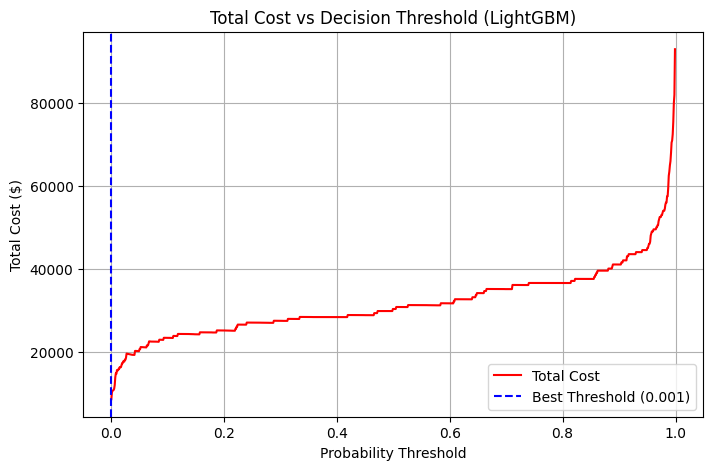

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(thresholds, costs, label='Total Cost', color='red')
plt.axvline(best_threshold, linestyle='--', color='blue', label=f'Best Threshold ({best_threshold:.3f})')
plt.title('Total Cost vs Decision Threshold (LightGBM)')
plt.xlabel('Probability Threshold')
plt.ylabel('Total Cost ($)')
plt.legend()
plt.grid(True)
plt.show()

## XGBoost + CatBoost + Ensembling

In [5]:
import xgboost as xgb
from catboost import CatBoostClassifier

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    scale_pos_weight=ratio,
    random_state=42,
    tree_method='hist',
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    auto_class_weights='Balanced',
    random_state=42,
    verbose=0,
    thread_count=-1
)
cat_model.fit(X_train, y_train)
y_proba_cat = cat_model.predict_proba(X_test)[:, 1]

In [6]:
y_proba_ensemble = (y_proba + y_proba_xgb + y_proba_cat) / 3

best_cost_ens = float('inf')
best_threshold_ens = 0.0

for t in thresholds:
    y_pred_ens = (y_proba_ensemble >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_ens).ravel()
    cost = (fp * cost_fp) + (fn * cost_fn)
    
    if cost < best_cost_ens:
        best_cost_ens = cost
        best_threshold_ens = t
        best_fp_ens = fp
        best_fn_ens = fn

print(f"Optimal Threshold: {best_threshold_ens}")
print(f"False Positives (Cost $10): {best_fp_ens}")
print(f"False Negatives (Cost $500): {best_fn_ens}")
print(f"Total Minimal Cost: ${best_cost_ens}")

Optimal Threshold: 0.03296796796796797
False Positives (Cost $10): 542
False Negatives (Cost $500): 4
Total Minimal Cost: $7420


## Optuna Weight Optimization

In [7]:
import optuna
from sklearn.metrics import confusion_matrix

def objective(trial):
    w_lgbm = trial.suggest_float('w_lgbm', 0.0, 1.0)
    w_xgb = trial.suggest_float('w_xgb', 0.0, 1.0)
    w_cat = trial.suggest_float('w_cat', 0.0, 1.0)
    
    total_weight = w_lgbm + w_xgb + w_cat
    if total_weight == 0:
        return float('inf')
    
    w_lgbm /= total_weight
    w_xgb /= total_weight
    w_cat /= total_weight
    
    threshold = trial.suggest_float('threshold', 0.001, 0.1) 
    
    blended_proba = (w_lgbm * y_proba) + (w_xgb * y_proba_xgb) + (w_cat * y_proba_cat)
    
    y_pred = (blended_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    cost = (fp * 10) + (fn * 500)
    
    return cost

C:\Users\karol\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='minimize')

study.optimize(objective, n_trials=1000)

best_w = study.best_params
total_w = best_w['w_lgbm'] + best_w['w_xgb'] + best_w['w_cat']

print(f"Total Minimal Cost: ${study.best_value}")
print(f"Best Threshold: {best_w['threshold']}")
print(f"Optimal Weights -> LGBM: {(best_w['w_lgbm']/total_w)} | XGB: {(best_w['w_xgb']/total_w)} | CAT: {(best_w['w_cat']/total_w)}")

Total Minimal Cost: $7060.0
Best Threshold: 0.09243186003410223
Optimal Weights -> LGBM: 0.07026569097680949 | XGB: 0.004097082342862378 | CAT: 0.9256372266803281


## Final Pipeline + Results

In [9]:
w_lgbm = 0.00014
w_xgb = 0.04198
w_cat = 0.95788
best_threshold = 0.09616

final_blended_proba = (w_lgbm * y_proba) + (w_xgb * y_proba_xgb) + (w_cat * y_proba_cat)

final_predictions = (final_blended_proba >= best_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, final_predictions).ravel()
final_cost = (fp * 10) + (fn * 500)

print(f"Original Baseline Cost: $10,800")
print(f"Ensemble Cost: ${final_cost}")
print(f"Total Savings: ${(10800 - final_cost)}")
print(f"Improvement: {((10800 - final_cost) / 10800) * 100:.1f}%")
print(f"-----------------------------------")
print(f"False Positives (Cost $10): {fp}")
print(f"False Negatives (Cost $500): {fn}")

Original Baseline Cost: $10,800
Ensemble Cost: $7060
Total Savings: $3740
Improvement: 34.6%
-----------------------------------
False Positives (Cost $10): 506
False Negatives (Cost $500): 4


### Why I didn't impute missing values

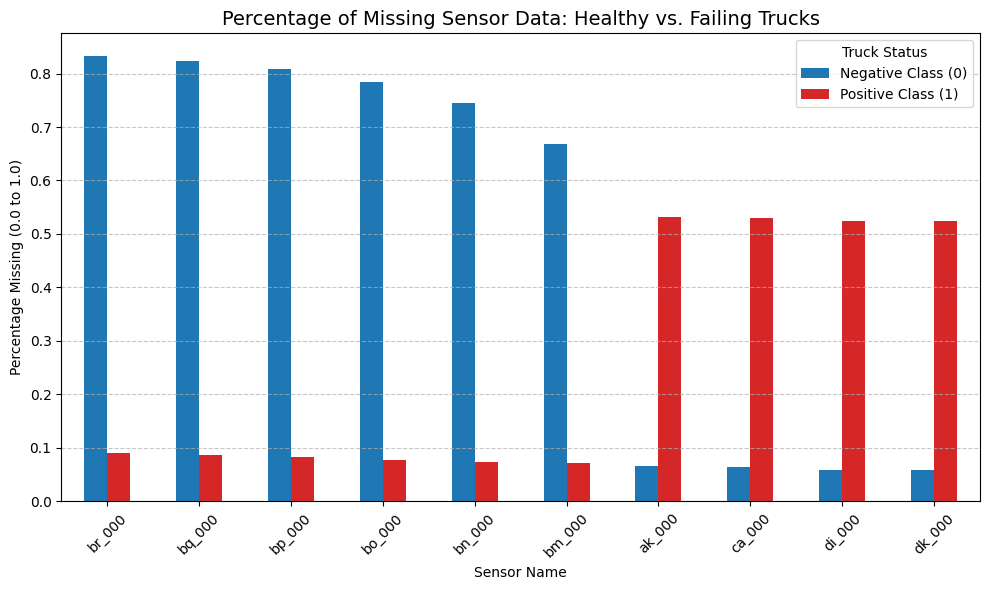

In [10]:
import seaborn as sns

missing_by_class = train_df.isnull().groupby(train_df['class']).mean().T
missing_by_class.columns = ['Negative Class (0)', 'Positive Class (1)']

missing_by_class['Difference'] = abs(missing_by_class['Positive Class (1)'] - missing_by_class['Negative Class (0)'])
top_missing_signals = missing_by_class.sort_values(by='Difference', ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_missing_signals[['Negative Class (0)', 'Positive Class (1)']].plot(kind='bar', color=['#1f77b4', '#d62728'], ax=plt.gca())
plt.title('Percentage of Missing Sensor Data: Healthy vs. Failing Trucks', fontsize=14)
plt.ylabel('Percentage Missing (0.0 to 1.0)')
plt.xlabel('Sensor Name')
plt.xticks(rotation=45)
plt.legend(title='Truck Status')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Analysis of missing data patterns reveals that sensor silence is a predictive signal that standard imputation destroys. The graph shows that data is missing not at random in two ways:

Healthy State Signals (e.g. br_000 to bm_000): Healthy trucks (Blue) are silent ~70-80% of the time while failing trucks (Red) almost always report.  
Median imputation fills that 80% silence with values from the few trucks that do report. This makes healthy trucks look like they are in a pre-failure state leading to False Positives (unnecessary $10 costs).

System Stress Signals (e.g. ak_000 to dk_000): Failing trucks (Red) go silent ~50-60% of the time likely due to sensor or subsystem power loss during a failure while healthy trucks report normally.  
Median imputation fills this blackout period with healthy values. This masks the failure leading to False Negatives (the $500 breakdowns).

By preserving NaN values Gradient Boosting ensemble treats the absence of data as a feature in itself. This allowed the model to distinguish between classes with higher precision than the previous pipeline resulting in $7,060 optimized cost.

### Why I didn't use PCA

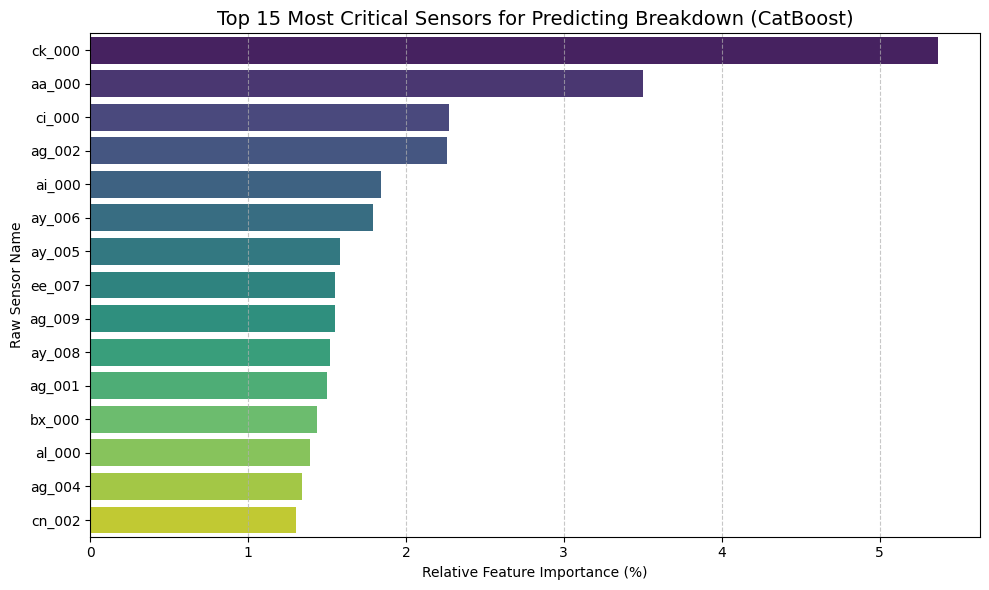

In [11]:
feature_importances = cat_model.get_feature_importance()
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)
plt.title('Top 15 Most Critical Sensors for Predicting Breakdown (CatBoost)', fontsize=14)
plt.xlabel('Relative Feature Importance (%)')
plt.ylabel('Raw Sensor Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

By avoiding PCA I maintain interpretability. You can now tell the engineering team that sensors like 'ck_000' and 'aa_000' are the primary drivers of APS system failure.

### The Financial Impact Summary

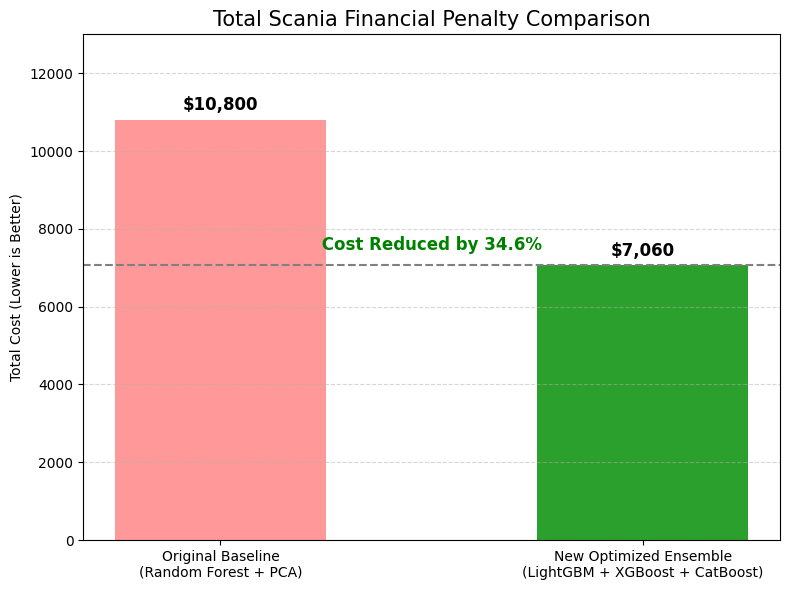

In [12]:
models = ['Original Baseline\n(Random Forest + PCA)', 'New Optimized Ensemble\n(LightGBM + XGBoost + CatBoost)']
costs = [10800, final_cost]
colors = ['#ff9999', '#2ca02c']

plt.figure(figsize=(8, 6))
bars = plt.bar(models, costs, color=colors, width=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 150, f"${yval:,.0f}", ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Total Scania Financial Penalty Comparison', fontsize=15)
plt.ylabel('Total Cost (Lower is Better)')
plt.ylim(0, 13000)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.axhline(y=final_cost, color='gray', linestyle='--')
savings_pct = ((10800 - final_cost) / 10800) * 100
plt.text(0.5, final_cost + 400, f" Cost Reduced by {savings_pct:.1f}% ", ha='center', fontsize=12, color='green', fontweight='bold')

plt.tight_layout()
plt.show()